In [1]:
# ============================================================
#  NOTEBOOK 03: CONSULTAS GERENCIALES EN MONGODB ATLAS (Grupo 3)
#  Responde preguntas de gestion sobre la demanda hospitalaria
# ============================================================
import os
import pandas as pd
from pymongo import MongoClient
from dotenv import load_dotenv

# Cargar la conexion desde el .env (la misma que usa upload_mongodb.py)
load_dotenv('../.env')   # el .env esta en la raiz, por eso ../
MONGO_URI = os.getenv("MONGO_URI")

# Conectar a la base de datos del grupo
cliente = MongoClient(MONGO_URI)
db = cliente["bigdata_g3"]
coleccion = db["demanda_diaria"]

# Verificar la conexion
total = coleccion.count_documents({})
print(f"Conexion exitosa a MongoDB Atlas")
print(f"Total de documentos en la coleccion 'demanda_diaria': {total:,}")

Conexion exitosa a MongoDB Atlas
Total de documentos en la coleccion 'demanda_diaria': 13,152


In [2]:
# ============================================================
#  CONSULTA 1: ¿Cual fue el dia mas critico por casos de dengue?
#  (Pregunta gerencial del README)
# ============================================================

# Pipeline de agregacion de MongoDB: ordenar por casos de dengue y traer el top 10
pipeline = [
    {"$sort": {"casos_dengue_semana": -1}},
    {"$limit": 10},
    {"$project": {
        "_id": 0,
        "fecha_atencion": 1,
        "establecimiento_nombre": 1,
        "especialidad": 1,
        "casos_dengue_semana": 1,
        "total_pacientes_diarios": 1
    }}
]

resultado = list(coleccion.aggregate(pipeline))
df_critico = pd.DataFrame(resultado)

print("TOP 10 registros con mas casos de dengue (semanas mas criticas):")
print(df_critico.to_string(index=False))

print(f"\nEl pico de dengue se registro el: {df_critico.iloc[0]['fecha_atencion']}")
print(f"Con {df_critico.iloc[0]['casos_dengue_semana']:.0f} casos de dengue esa semana.")

TOP 10 registros con mas casos de dengue (semanas mas criticas):
fecha_atencion establecimiento_nombre  especialidad  total_pacientes_diarios  casos_dengue_semana
    2023-03-24    Hospital Rebagliati    Emergencia                       55                435.0
    2023-03-26    Hospital Rebagliati Traumatologia                       28                435.0
    2023-03-26       Hospital Sabogal   Cardiologia                       29                435.0
    2023-03-26      Hospital Almenara    Emergencia                       44                435.0
    2023-03-23       Hospital Sabogal    Emergencia                       45                435.0
    2023-03-23    Hospital Rebagliati   Cardiologia                       30                435.0
    2023-03-20       Hospital Sabogal Traumatologia                       21                435.0
    2023-03-22      Hospital Almenara   Cardiologia                       26                435.0
    2023-03-22      Hospital Almenara    Emergencia  

Demanda total por especialidad:
    especialidad  total_pacientes
Medicina Interna           251368
     Cardiologia            87779
      Emergencia            87647
   Traumatologia            73206


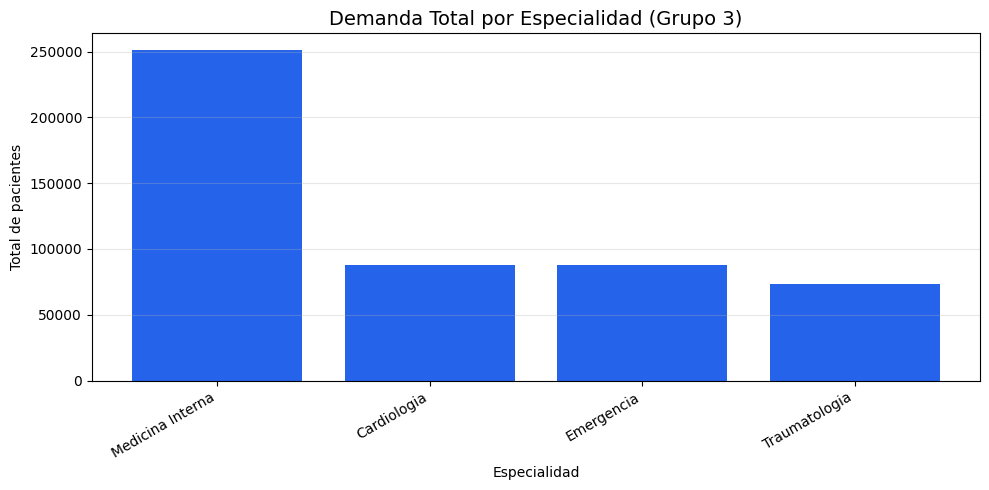


La especialidad con mayor demanda es: Medicina Interna


In [3]:
# ============================================================
#  CONSULTA 2: ¿Que especialidades reciben mas pacientes?
#  Ayuda a decidir donde concentrar medicos y recursos
# ============================================================

pipeline_esp = [
    {"$group": {
        "_id": "$especialidad",
        "total_pacientes": {"$sum": "$total_pacientes_diarios"}
    }},
    {"$sort": {"total_pacientes": -1}}
]

resultado_esp = list(coleccion.aggregate(pipeline_esp))
df_esp = pd.DataFrame(resultado_esp)
df_esp.columns = ['especialidad', 'total_pacientes']

print("Demanda total por especialidad:")
print(df_esp.to_string(index=False))

# Grafico de barras
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(df_esp['especialidad'], df_esp['total_pacientes'], color='#2563eb')
plt.title('Demanda Total por Especialidad (Grupo 3)', fontsize=14)
plt.xlabel('Especialidad'); plt.ylabel('Total de pacientes')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLa especialidad con mayor demanda es: {df_esp.iloc[0]['especialidad']}")

In [4]:
# ============================================================
#  CONSULTA 3: ¿Que hospital tiene mayor ocupacion de camas?
#  Identifica el establecimiento mas saturado
# ============================================================

pipeline_ocup = [
    {"$group": {
        "_id": "$establecimiento_nombre",
        "ocupacion_promedio": {"$avg": "$tasa_ocupacion_promedio"},
        "total_pacientes": {"$sum": "$total_pacientes_diarios"}
    }},
    {"$sort": {"ocupacion_promedio": -1}}
]

resultado_ocup = list(coleccion.aggregate(pipeline_ocup))
df_ocup = pd.DataFrame(resultado_ocup)
df_ocup.columns = ['establecimiento', 'ocupacion_promedio', 'total_pacientes']

# Convertir ocupacion a porcentaje para que se lea mejor
df_ocup['ocupacion_%'] = (df_ocup['ocupacion_promedio'] * 100).round(1)

print("Ocupacion promedio de camas por establecimiento:")
print(df_ocup[['establecimiento', 'ocupacion_%', 'total_pacientes']].to_string(index=False))

print(f"\nEl hospital mas saturado es: {df_ocup.iloc[0]['establecimiento']}")
print(f"Con una ocupacion promedio de {df_ocup.iloc[0]['ocupacion_%']:.1f}%")
print("\nNOTA: Una ocupacion >85% indica saturacion (meta EsSalud: 85-90%)")

Ocupacion promedio de camas por establecimiento:
    establecimiento  ocupacion_%  total_pacientes
Hospital Rebagliati         92.4           166415
  Hospital Almenara         92.4           166675
   Hospital Sabogal         92.3           166910

El hospital mas saturado es: Hospital Rebagliati
Con una ocupacion promedio de 92.4%

NOTA: Una ocupacion >85% indica saturacion (meta EsSalud: 85-90%)
